In [1]:
# import dependencies
import pandas as pd
import numpy as np
import geopandas as gpd
import fiona
import matplotlib.pyplot as plt

## GIS Map Data

Load shapefiles, convert to a standard web mapping projection (CRS - Coordinate Reference System) for compatibility with Leaflet, drop extraneous columns, save to GeoJSON

#### Census Town Boundaries

In [2]:
# open shapefile
fp = "../data/raw/census_shp/tl_2025_50_cousub.shp"
gdf_census = gpd.read_file(fp)

In [3]:
# check projection
print(gdf_census.crs)

# convert to WGS84
gdf_census = gdf_census.to_crs("EPSG:4326")

# check projection
print(gdf_census.crs)

EPSG:4269
EPSG:4326


In [4]:
gdf_census.columns

Index(['STATEFP', 'COUNTYFP', 'COUSUBFP', 'COUSUBNS', 'GEOID', 'GEOIDFQ',
       'NAME', 'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry'],
      dtype='object')

May want to include COUNTYFP (county FIPS, to group by county), NAMELSAD (full town name), ALAND or AWATER (Census calculated land or water area)

        GEOID         NAME          NAMELSAD      ALAND   AWATER  \
0  5001523500         Eden         Eden town  162970286  2552928   
1  5002548400      Newfane      Newfane town  102981054   697246   
2  5002560250   Rockingham   Rockingham town  107252397  2011216   
3  5002581400  Westminster  Westminster town  116613918   669527   
4  5002584850      Windham      Windham town   67581474   211573   

                                            geometry  
0  POLYGON ((-72.66139 44.70192, -72.66084 44.702...  
1  POLYGON ((-72.7755 42.92638, -72.77376 42.9292...  
2  POLYGON ((-72.55798 43.12776, -72.55798 43.128...  
3  POLYGON ((-72.58564 43.02324, -72.58491 43.027...  
4  POLYGON ((-72.77335 43.1539, -72.77256 43.1547...  


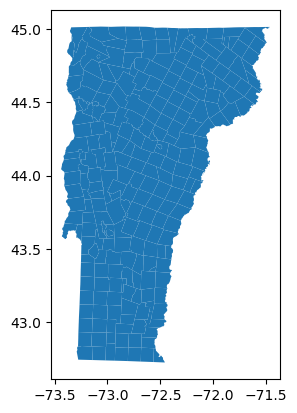

In [5]:
# prune to only include relevant columns
gdf_census = gdf_census[["GEOID", "NAME", "NAMELSAD", "ALAND", "AWATER", "geometry"]]
print(gdf_census.head())

# save to geojson for eda and javascript mapping
gdf_census.to_file("../data/cleaned/census.geojson", driver="GeoJSON")

# plot the data
gdf_census.plot()
plt.show()

#### FEMA National Flood Hazard Layer (NFHL)

In [6]:
# load FEMA NFHL geodatabase to extract flood hazard zones
gdb_path = "../data/raw/FEMA_NFHL/NFHL_50_20241002.gdb"
gdf_flood = gpd.read_file(gdb_path, layer="S_FLD_HAZ_AR")
gdf_flood["FLD_ZONE"].value_counts()

c:\Users\johbr\anaconda3\envs\dev\lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


FLD_ZONE
X                    3605
AE                   3156
A                     816
AH                      4
AO                      3
D                       3
OPEN WATER              3
AREA NOT INCLUDED       1
Name: count, dtype: int64

In [7]:
# check projection
print(gdf_flood.crs)

# convert to WGS84
gdf_flood = gdf_flood.to_crs(epsg=4326)

# check the conversion
print(gdf_flood.crs)

EPSG:4269
EPSG:4326


In [8]:
gdf_flood.columns

Index(['DFIRM_ID', 'VERSION_ID', 'FLD_AR_ID', 'STUDY_TYP', 'FLD_ZONE',
       'ZONE_SUBTY', 'SFHA_TF', 'STATIC_BFE', 'V_DATUM', 'DEPTH', 'LEN_UNIT',
       'VELOCITY', 'VEL_UNIT', 'AR_REVERT', 'AR_SUBTRV', 'BFE_REVERT',
       'DEP_REVERT', 'DUAL_ZONE', 'SOURCE_CIT', 'GFID', 'SHAPE_Length',
       'SHAPE_Area', 'geometry'],
      dtype='object')

May want ZONE_SUBTY for details (e.g., coastal vs riverine)

  FLD_ZONE                                           geometry
0        A  MULTIPOLYGON (((-72.12902 43.99176, -72.12887 ...
1        A  MULTIPOLYGON (((-72.12232 43.99935, -72.12231 ...
2        A  MULTIPOLYGON (((-72.07878 44.11805, -72.07877 ...
3        A  MULTIPOLYGON (((-72.10734 44.04262, -72.1073 4...
4        A  MULTIPOLYGON (((-72.12935 44.064, -72.12935 44...


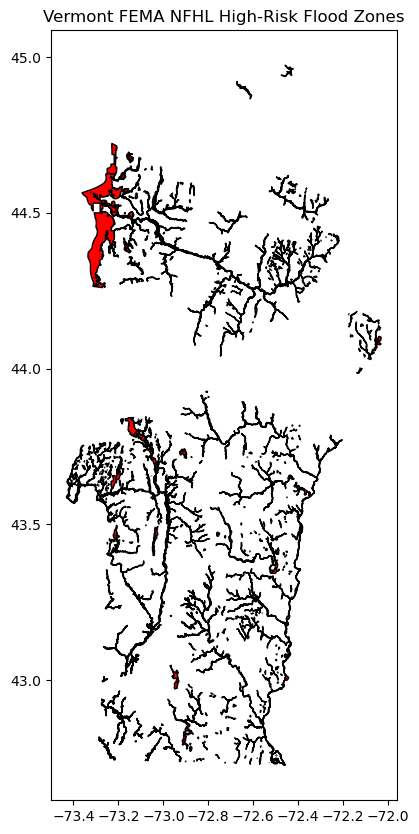

In [9]:
# extract high-risk zones (AE, A, AH, AO)
gdf_high_risk = gdf_flood[gdf_flood["FLD_ZONE"].isin(["AE", "A", "AH", "AO"])]

# prune columns
gdf_high_risk = gdf_high_risk[["FLD_ZONE", "geometry"]]
print(gdf_high_risk.head())

# save to geojson for eda and javascript mapping
gdf_high_risk.to_file("../data/cleaned/nfhl.geojson", driver="GeoJSON")

# plot the high-risk zones
gdf_high_risk.plot(figsize=(10, 10), color="red", edgecolor="black")
plt.title("Vermont FEMA NFHL High-Risk Flood Zones")
plt.show()

#### State of Vermont River Corridors

In [10]:
# load river corridor polygons
rc_fp = "../data/raw/VT_river_corridors/WaterHydro_RiverCorridors_poly.shp"
gdf_rc = gpd.read_file(rc_fp)

In [11]:
# check projection
print(gdf_rc.crs)

# convert to WGS84
gdf_rc = gdf_rc.to_crs(epsg=4326)

# check projection
print(gdf_rc.crs)

PROJCS["NAD83 / Vermont",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",42.5],PARAMETER["central_meridian",-72.5],PARAMETER["scale_factor",0.999964285714286],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
EPSG:4326


In [12]:
gdf_rc.columns

Index(['OBJECTID', 'SGAT_ID', 'MEAN_DA_sq', 'MEAN_Bkful', 'FIRST_GNIS',
       'DA_sqmi_f', 'Bkful_ft', 'ER_Power', 'DEP_Power', 'GNIS_NAME',
       'P1_ChMult', 'MN_DMS_ChW', 'MNP1ChMult', 'MNP2ChMult', 'F1stER_Pow',
       'F1stDEP_Po', 'geometry'],
      dtype='object')

  GNIS_NAME                                           geometry
0      None  POLYGON ((-72.30781 43.70534, -72.30782 43.704...
1      None  POLYGON ((-72.31572 43.7166, -72.31572 43.7165...
2      None  POLYGON ((-72.31229 43.71724, -72.31247 43.716...
3      None  POLYGON ((-72.31817 43.72665, -72.31817 43.726...
4      None  POLYGON ((-72.32036 43.72615, -72.32054 43.726...


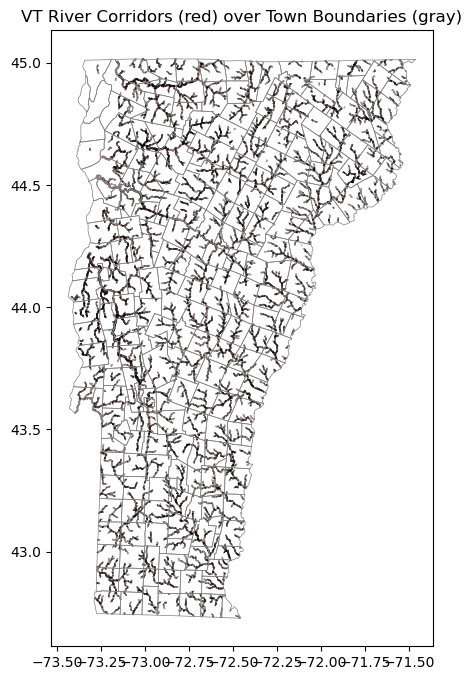

In [13]:
# prune to relevant columns
gdf_rc = gdf_rc[["GNIS_NAME", "geometry"]]
print(gdf_rc.head())

# save to geojson for eda and javascript mapping
gdf_rc.to_file("../data/cleaned/river_corridors.geojson", driver="GeoJSON")

# plot the data
ax = gdf_census.boundary.plot(figsize=(8, 8), color="gray", linewidth=0.5)
gdf_rc.plot(ax=ax, color="red", alpha=0.4, edgecolor="black")
plt.title("VT River Corridors (red) over Town Boundaries (gray)")
plt.show()

## Calculate Land Area

Convert map data to an equal-area projection before making calculations

In [14]:
# reproject all to equal-area CRS for accurate area calculations
gdf_census_proj = gdf_census.to_crs("EPSG:5070")
gdf_rc_proj = gdf_rc.to_crs("EPSG:5070")
gdf_high_risk_proj = gdf_high_risk.to_crs("EPSG:5070")

In [15]:
# calculate town area (in square meters)
gdf_census_proj["town_area_sqm"] = gdf_census_proj.geometry.area

In [16]:
# calculate percent river corridor per town
river_percents = []
for idx, town in gdf_census_proj.iterrows():
    intersection = gpd.overlay(
        gpd.GeoDataFrame([town], crs=gdf_census_proj.crs),
        gdf_rc_proj,
        how="intersection",
    )
    rc_area = intersection.geometry.area.sum()
    percent_rc = (rc_area / town.town_area_sqm) * 100 if town.town_area_sqm > 0 else 0
    river_percents.append(percent_rc)
gdf_census_proj["pct_river_corridor"] = river_percents

In [17]:
# calculate percent high-risk flood zone per town
flood_percents = []
for idx, town in gdf_census_proj.iterrows():
    intersection = gpd.overlay(
        gpd.GeoDataFrame([town], crs=gdf_census_proj.crs),
        gdf_high_risk_proj,
        how="intersection",
    )
    flood_area = intersection.geometry.area.sum()
    percent_flood = (
        (flood_area / town.town_area_sqm) * 100 if town.town_area_sqm > 0 else 0
    )
    flood_percents.append(percent_flood)
gdf_census_proj["pct_high_risk_NFHL"] = flood_percents

In [18]:
# save to a new df for export
town_df = gdf_census_proj[
    [
        "GEOID",
        "NAMELSAD",
        "ALAND",
        "AWATER",
        "town_area_sqm",
        "pct_river_corridor",
        "pct_high_risk_NFHL",
    ]
].rename(
    columns={
        "NAMELSAD": "town_name",
        "ALAND": "aland_sqm",
        "AWATER": "awater_sqm",
    }
)
# round town_area_sqm to nearest whole number for easier interpretation
town_df.loc[:, "town_area_sqm"] = town_df["town_area_sqm"].round(0).astype(int)

# display, alphabetize, and export
display(town_df.head())
town_df = town_df.sort_values("town_name")
town_df.to_csv("../data/cleaned/town_flood_risk.csv", index=False)

,GEOID,town_name,aland_sqm,awater_sqm,town_area_sqm,pct_river_corridor,pct_high_risk_NFHL
0,5001523500,Eden town,162970286,2552928,165523226.0,1.760724,0.000000
1,5002548400,Newfane town,102981054,697246,103678298.0,4.744363,1.780801
2,5002560250,Rockingham town,107252397,2011216,109263619.0,3.544192,5.106042
3,5002581400,Westminster town,116613918,669527,117283434.0,1.867759,5.799134
4,5002584850,Windham town,67581474,211573,67793053.0,1.320451,2.157417


Note that the calculated town area closely aligns with ALAND from the census